MAE: 5033.27


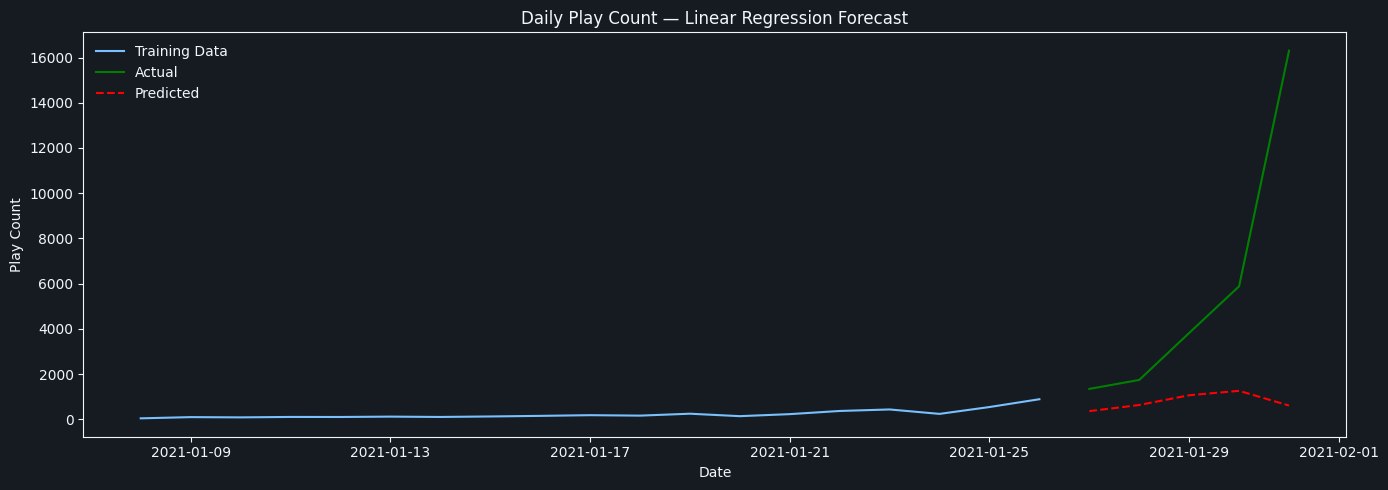

In [4]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt

# Load and parse
df = pd.read_csv('fm_data.csv')
df['datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], dayfirst=True)

# Daily play counts for one user
user = 'Babs_05'
ts = df[df['Username'] == user].groupby(df['datetime'].dt.date).size()
ts.index = pd.to_datetime(ts.index)
ts = ts.asfreq('D').fillna(0).reset_index()
ts.columns = ['date', 'play_count']

# Features: day of week, day of month, month, and lag-7 (last week's count)
ts['day_of_week'] = ts['date'].dt.dayofweek
ts['day_of_month'] = ts['date'].dt.day
ts['month'] = ts['date'].dt.month
ts['lag_7'] = ts['play_count'].shift(7)  # play count 7 days ago

# Drop rows where lag_7 is NaN (first 7 days)
ts = ts.dropna()

# Define X and y
X = ts[['day_of_week', 'day_of_month', 'month', 'lag_7']]
y = ts['play_count']

# Temporal train/test split — 80/20
split = int(len(ts) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# Train
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Evaluate
print(f'MAE: {mean_absolute_error(y_test, y_pred):.2f}')

# Plot
plt.figure(figsize=(14, 5))
plt.plot(ts['date'][:split], y_train, label='Training Data')
plt.plot(ts['date'][split:], y_test, label='Actual', color='green')
plt.plot(ts['date'][split:], y_pred, label='Predicted', color='red', linestyle='--')
plt.title('Daily Play Count — Linear Regression Forecast')
plt.xlabel('Date')
plt.ylabel('Play Count')
plt.legend()
plt.tight_layout()
plt.show()